In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import ndimage as ndi
from ase import io as aio
import abtem

from gas.PDFs.RDFs import RDF
from gas.PDFs.RDF_2D import RDF_2D
from gas.PDFs.PDF_3body import PDF3B
from gas.PDFs.PDFs_utils.PDF_show import plot_RDF3b, plot_r1r2_RDF3b
from gas.io.xyz import load_xyz
from datetime import datetime 


try:
    import cupy as cp
    if cp.cuda.is_available():
        print(f"Found {cp.cuda.runtime.getDeviceCount()} GPUs")
        device = 1
        print(f"Will use GPU {device}")
        cp.cuda.Device(device).use()
    else:
        print("No GPUs found, using CPU")
        device='cpu'
except (ImportError, ModuleNotFoundError):
    print("No GPUs found, using CgPU")
    device='cpu'

Found 4 GPUs
Will use GPU 1


1. make a nanocrystal seeded volume
    - could even take from the amorphous carbon dataset, or one of the existing SiO or Al2O3 datasets
    - actually for now just steal any of the "initial" xyz files from most recent Haili batch 
2. calculate PDFs, and then with varying degrees of variation 

In [3]:
tdir = Path("~/data/distillery/structures/Al2O3/3_90_overlap/").expanduser()

init_file = next(tdir.glob("*initial.xyz"))
relax_file = next(tdir.glob("*relaxed.xyz"))
quench_file = next(tdir.glob("*quenched.xyz"))

init_file


PosixPath('/home/amccray/data/distillery/structures/Al2O3/3_90_overlap/Al2O3_3_90_overlap_initial.xyz')

# Downloading structures from materials project

In [ ]:
from mp_api.client import MPRester
from pymatgen.io.cif import CifWriter

mp_code = "mp-1143"

with MPRester(api_key="qLBVwWWckIrrZoY4Eklu3cVggHJ79lOC") as mpr:
    mat_data = mpr.materials.search(material_ids=[mp_code])[0]
    # print(mat_data)

mat_name = mat_data.formula_pretty
outdir = Path(f"~/data/distillery/structures/{mat_name}").expanduser()
outfile = outdir / f"{mat_name}_{str(mat_data.symmetry.crystal_system).lower()}_{mp_code}.cif"
print(outfile)
assert outdir.exists() 
w = CifWriter(mat_data.structure)
w.write_file(outfile)

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

/home/amccray/data/distillery/structures/Al2O3/Al2O3_trigonal_mp-1143.cif


# Gaussian noise for each atom

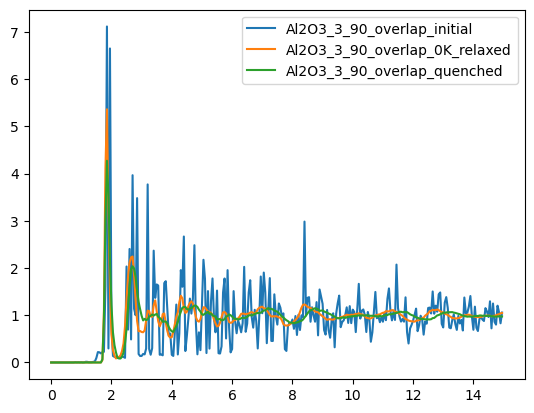

In [34]:
RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}

rdf = RDF(device=device, v=0)
fig, ax = plt.subplots()

gr_3Ds = {}

for f, nm in zip([init_file, relax_file, quench_file], ["init", "relax", "quench"]): 
    atoms = load_xyz(f, v=0)
    
    r, gr_3D = rdf.rdf(
        atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
    )
    r = r.get()
    gr_3D=gr_3D.get()
    gr_3Ds[nm] = gr_3D
    gr_3Ds['r'] = r

    ax.plot(r, gr_3D, label=f.stem)
    
ax.legend() 
plt.show()
    

loading file: Al2O3_3_90_overlap_quenched.xyz
# atoms: 199560
Atoms(symbols='Al79799O119761', pbc=True, cell=[88.84597917112492, 90.52096313660806, 228.25698542633242], id=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


  0%|          | 0/3 [00:00<?, ?it/s]

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.109 atoms / A^3
N_max_neighbors:  9220
-- done --
Total time (h:m:s) 0:00:00.05
Center atoms per sec: 39_717.02

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5


 67%|██████▋   | 2/3 [00:00<00:00,  4.73it/s]

Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.109 atoms / A^3
N_max_neighbors:  9220
-- done --
Total time (h:m:s) 0:00:00.333
Center atoms per sec: 5_988.51

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5


100%|██████████| 3/3 [00:00<00:00,  4.50it/s]

Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.109 atoms / A^3
N_max_neighbors:  9220
-- done --
Total time (h:m:s) 0:00:00.227
Center atoms per sec: 8_797.75



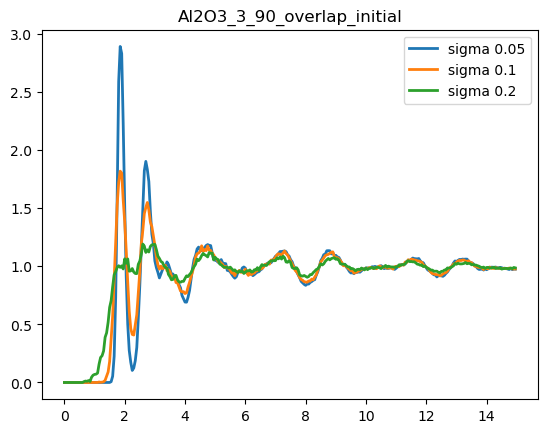

In [36]:
RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}

# sigmas = [0.01, 0.02, 0.03]
sigmas = [0.05, 0.1, 0.2]
# sigmas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

gr_3Dsigmas = {}

rdf = RDF(device=device, v=3)
# atoms2 = load_xyz(init_file, v=3) 
atoms2 = load_xyz(quench_file, v=3) 
for sigma in tqdm(sigmas):
    jitter = np.random.normal(loc=0, scale=sigma, size=atoms2.positions.shape)
    atoms2.positions += jitter
    atoms2.wrap() 

    rs, gr_3D_sigma = rdf.rdf(
        atoms2,
        pbcs=atoms2.pbc,
        **RDF_params, 
    )
    gr_3D_sigma = gr_3D_sigma.get()
    gr_3Dsigmas[f"gr_sigma_{sigma}"] = gr_3D_sigma 

gr_3Dsigmas['r'] = rs.get() 
fig, ax = plt.subplots()
# ax.plot(r, gr_3Dsigmas['init'], label='no jitter')

for sigma in sigmas: 
    ax.plot(gr_3Dsigmas['r'], gr_3Dsigmas[f"gr_sigma_{sigma}"], label=f'sigma {sigma}', lw = 2)
ax.legend()
ax.set_title(init_file.stem)
plt.show()
    

In [ ]:
fig, ax = plt.subplots()
ax.plot(gr_3Ds['r'], gr_3Ds['init']+8, label='initial')
ax.plot(gr_3Ds['r'], gr_3Ds['quench']+5, label='quench')
# ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.01']+3, label='sigma 0.01')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.05']+2, label='sigma 0.05')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.1']+0, label='sigma 0.1')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.2']-1, label='sigma 0.2')
ax.legend()
ax.set_title(f"Quenched vs initial+jitter | {quench_file.stem}")
ax.set_ylabel("g(r)")
ax.set_xlabel("r (A)")
plt.show()


# Improved orientation mixing with rotations and such 
- use init file
- rotation of random blocks
- BZA spline + vortex operations or gaussians, + normalization 
    - long range variation in displacement 
- last pass do a repulsion check 

loading file: Al2O3_3_90_overlap_quenched.xyz
# atoms: 199560
Atoms(symbols='Al79799O119761', pbc=True, cell=[88.84597917112492, 90.52096313660806, 228.25698542633242], id=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)
Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.109 atoms / A^3
N_max_neighbors:  9220
-- done --
Total time (h:m:s) 0:00:00.291
Center atoms per sec: 6_863.27



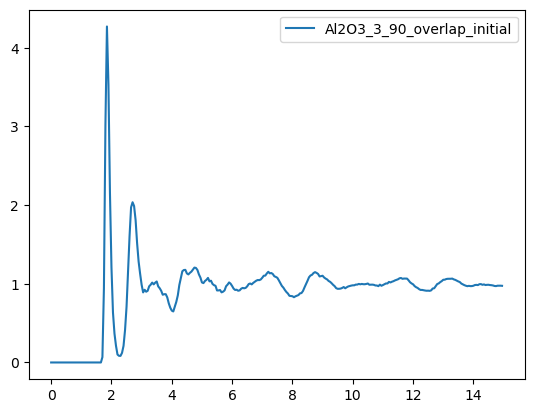

In [4]:
# f = next(tdir.glob("../*crystal.xyz"))
f = quench_file
atoms = load_xyz(f, v=1)

RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}
rdf = RDF(device=device, v=1)
r, gr_init = rdf.rdf(
        atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
)
gr_init = gr_init.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label=init_file.stem)
ax.legend() 
plt.show()
    

In [5]:
from gas.generation.nc_seeds import load_and_prepare_xyz, add_seeds_to_amorphous_block
from gas.generation.utils import get_nanocrystalline_grains, orient_and_shift_grain, get_voronoi_bisectors, get_cell_info

Sampling nanocrystalline seeds
# voronoi points/cells:  229


<Axes: xlabel='x [Å]', ylabel='y [Å]'>

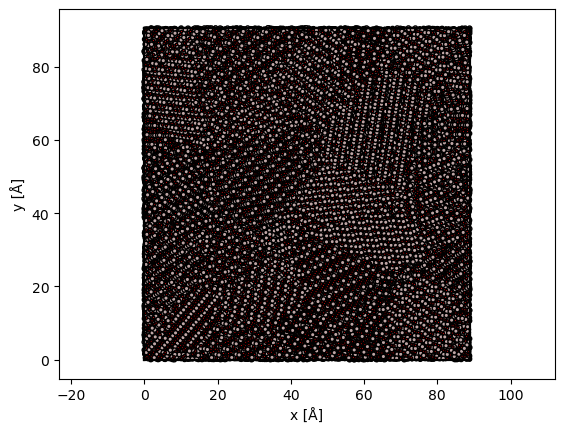

In [ ]:
# cell_data = get_cell_info(init_file)
# f = quench_file
# atoms = load_xyz(f, v=1)

cell_data = {
    "pbc": np.array([True,True,False]),
    "cell_orig": [0,0,0], # atoms.get_cell().array, # atoms.cell, # np.eye(3) * atoms.cell, 
}

starting_block = atoms.copy()
# crystal_cif = Path("../../generation/example_files/mp-149_as_Au.cif")
crystal_cif = Path("~/data/distillery/structures/Al2O3/Al2O3_trigonal_mp-1143.cif").expanduser()
config = {
    "seed_crystal": crystal_cif,  # which crystal to use as a seed grain
    "pbc": (True, True, False),  # pbc of scene
    "min_dist": 8,  # minimum distance between seed centers, in angstroms
    "N_seeds": 128,  # maximum number of seeds to include
    "density": 1/20**3,  # number density of seed centers, in N * angstrom ^ -3
    # "tolerance": 1.0,  # amount of excess space to exclude orig liquid atoms from
    "return_seeds": (
        return_seeds := True
    ),  # also return a scene with just the seed grains
}

if return_seeds:
    block_with_seeds, seeds = add_seeds_to_amorphous_block(starting_block, cell_data, **config)
    # seeds.to_file("SiO_seeds.xyz")
else:
    block_with_seeds = add_seeds_to_amorphous_block(starting_block, cell_data, **config)

# abtem.show_atoms(seeds.ase_atoms)


7034


<Axes: xlabel='x [Å]', ylabel='y [Å]'>

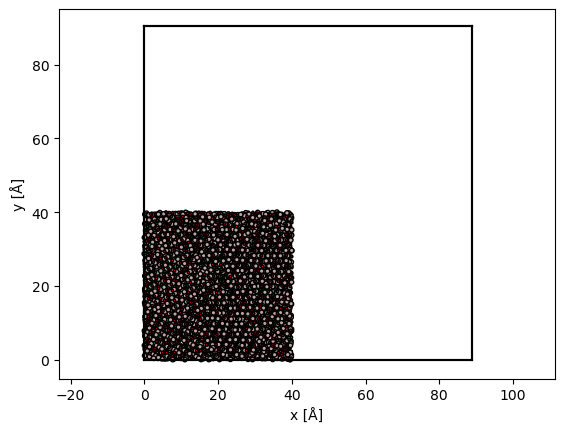

In [11]:

atoms_filt = block_with_seeds.ase_atoms.copy()
a = 40 
c = 40
m = (atoms_filt.positions[:,0] > a) | (atoms_filt.positions[:,1] > a) | (atoms_filt.positions[:,2] > c)
del atoms_filt[m]
print(len(atoms_filt))
abtem.show_atoms(atoms_filt)


In [8]:
# TODO get a SiO seed cif
# Replace the implanting seeds crystal -> same region but transformed
# allow for replacing x percent of volume
# running multiple times sequentially

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5
Proceeding with dr_ind of 0.5 despite losing 20 / 2.05e+05 atoms (0.010%)
Num total atoms in sim = 205055
Skip = 100, so calculating using 2051 atoms as centers
atomic density = 0.112 atoms / A^3
N_max_neighbors:  9474
-- done --
Total time (h:m:s) 0:00:01.478
Center atoms per sec: 1_387.24



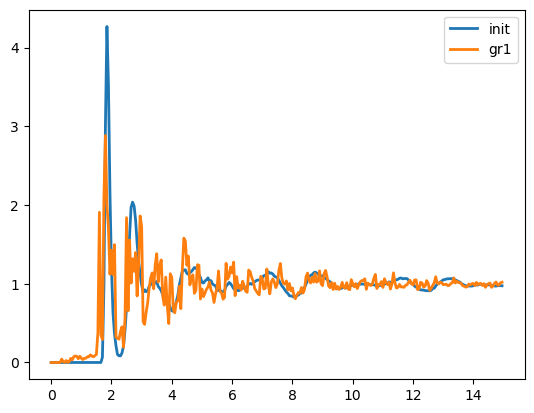

In [12]:
r, gr1 = rdf.rdf(
        block_with_seeds.ase_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr1 = gr1.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label='init', lw=2)
ax.plot(r, gr1, label='gr1', lw=2)
# ax.plot(r, gr1, label='gr1', linestyle='dotted', lw=2)
ax.legend() 
plt.show()
    

## custom CZone method

In [ ]:
# cell_data = get_cell_info(init_file)
# f = quench_file
# atoms = load_xyz(f, v=1)
from czone.molecule import Molecule
from czone.volume import MultiVolume, Plane, Volume, get_bounding_box, makeRectPrism
from gas.generation.utils import get_nanocrystalline_grains
from gas.generation.nc_seeds import get_nanocrystal_seeds, sample_grains
from czone.generator import Generator, NullGenerator
cell_data = {
    "pbc": np.array([True,True,False]),
    "cell_orig": [0,0,0], # atoms.get_cell().array, # atoms.cell, # np.eye(3) * atoms.cell, 
}

starting_block = atoms.copy()
# crystal_cif = Path("../../generation/example_files/mp-149_as_Au.cif")
crystal_cif = Path("~/data/distillery/structures/Al2O3/Al2O3_trigonal_mp-1143.cif").expanduser()
config = {
    "seed_crystal": crystal_cif,  # which crystal to use as a seed grain
    "pbc": (True, True, False),  # pbc of scene
    "min_dist": 8,  # minimum distance between seed centers, in angstroms
    "N_seeds": 128,  # maximum number of seeds to include
    "density": 1/20**3,  # number density of seed centers, in N * angstrom ^ -3
    "tolerance": 1e-5,  # amount of excess space to exclude orig liquid atoms from
    "return_seeds": (
        return_seeds := True
    ),  # also return a scene with just the seed grains
}

domain = {k:v for k, v in zip(('a', 'b', 'c'), tuple(np.diag(atoms.get_cell())))}

block_domain = makeRectPrism(**domain)
block_domain += cell_data['cell_orig']

domain['center'] = np.mean(block_domain, axis=0)

amor_atoms = Molecule.from_ase_atoms(atoms)
amor_block = Volume(points=block_domain, generator=amor_atoms)
amor_block.priority = 1

rng = np.random.default_rng()
## get nanocrystalline seeds
print("Sampling nanocrystalline seeds")
seed_grains = get_nanocrystal_seeds(domain, rng=rng, **config)
for seed in seed_grains:
    for p in seed.alg_objects:
        p.tol = config['tolerance']




# abtem.show_atoms(seeds.ase_atoms)


Sampling nanocrystalline seeds
# voronoi points/cells:  229


In [ ]:
from scipy.spatial.transform import Rotation as R 
from czone.transform import Rotation, Translation
from czone.scene import PeriodicScene
from czone.util.voxel import Voxel

starting_block = atoms.copy()
# crystal_cif = Path("../../generation/example_files/mp-149_as_Au.cif")
crystal_cif = Path("~/data/distillery/structures/Al2O3/Al2O3_trigonal_mp-1143.cif").expanduser()
config = {
    "seed_crystal": crystal_cif,  # which crystal to use as a seed grain
    "pbc": (True, True, False),  # pbc of scene
    "min_dist": 4,  # minimum distance between seed centers, in angstroms
    "N_seeds": 1500,  # maximum number of seeds to include
    "density": 1/10**3,  # number density of seed centers, in N * angstrom ^ -3
    "tolerance": 1e-10,  # amount of excess space to exclude orig liquid atoms from
    "return_seeds": (
        return_seeds := True
    ),  # also return a scene with just the seed grains
}

domain = {k:v for k, v in zip(('a', 'b', 'c'), tuple(np.diag(atoms.get_cell())))}

block_domain = makeRectPrism(**domain)
block_domain += cell_data['cell_orig']

domain['center'] = np.mean(block_domain, axis=0)

amor_atoms = Molecule.from_ase_atoms(atoms)
amor_block = Volume(points=block_domain, generator=amor_atoms)
amor_block.priority = 1

rng = np.random.default_rng(42)

print('getting grains')
all_grains = get_nanocrystalline_grains(
    min_dist=config["min_dist"], density=config["density"], domain=domain, rng=rng
)
seed_grains = sample_grains(all_grains, min_dist=config["min_dist"], N=config["N_seeds"], rng=rng)

print(f"{len(seed_grains)} / {len(all_grains)} seeds selected")

# TODO replace sample_grains with just picking indices at random (or all)
# and then for indices not chosen, separate list,
# so not joining with full amor_block at the end 

transformed_seeds = [] 
final_seeds = [] 
for cell in seed_grains: 
    goods = cell.checkIfInterior(amor_atoms.atoms)
    m = Molecule(species=amor_atoms.species[goods], positions=amor_atoms._atoms[goods], origin=amor_atoms.origin)
    # shift = (np.random.rand()-0.5)/2
    # shift = Translation(shift=np.array([1.0, 1.0, 1.0]))
    # m.transform(shift)
    theta = (np.random.rand()*2-1) * 45 
    # vec = np.array([0., 0, 1])
    vec = np.random.rand(3)
    vec /= np.linalg.norm(vec)
    rotmat = R.from_rotvec(vec*theta, degrees=True).as_matrix()
    rot = Rotation(matrix=rotmat, origin=m._atoms.mean(axis=0))
    m.transform(rot)
    cell._generator = m 

for seed in seed_grains:
    for p in seed.alg_objects:
        p.tol = config['tolerance']

final_seeds = []
for seed in tqdm(seed_grains):
    new_ex_grain = Volume(generator=NullGenerator(), priority=2)
    new_ex_grain.add_alg_object([Plane(p.normal, p.point + p.normal*config['tolerance'] ) for p in seed.alg_objects])
    seed_with_buffer = MultiVolume(volumes=[seed, new_ex_grain], priority=0)
    final_seeds.append(seed_with_buffer)
    
        
scene = PeriodicScene(
    domain=Voxel(atoms.get_cell(), origin=cell_data['cell_orig']),
    objects=[amor_block] + final_seeds,
    pbc=atoms.pbc,
)

print('starting populate')
scene.populate()
# scene.populate_no_collisions()
# grain_scene = PeriodicScene(
#     domain=scene.domain,
#     objects=final_seeds,
#     pbc=atoms.pbc,
# )
# grain_scene.populate()
# grain_scene.populate_no_collisions()
# abtem.show_atoms(grain_scene.ase_atoms)



1500 / 1836 seeds selected


100%|██████████| 1500/1500 [00:00<00:00, 3017.61it/s]


starting populate


In [32]:
scene.populate()


Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5
Proceeding with dr_ind of 0.5 despite losing 11 / 1.67e+05 atoms (0.007%)
Num total atoms in sim = 166671
Skip = 100, so calculating using 1667 atoms as centers
atomic density = 0.0908 atoms / A^3
N_max_neighbors:  7702
-- done --
Total time (h:m:s) 0:00:00.423
Center atoms per sec: 3_941.10



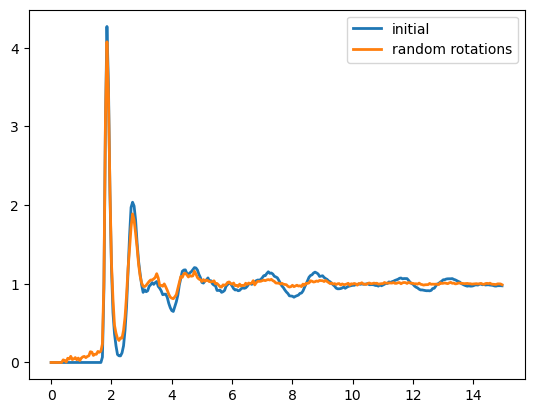

In [37]:
r, gr2 = rdf.rdf(
        scene.ase_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr2 = gr2.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label='initial', lw=2)
ax.plot(r, gr2, label='random rotations', lw=2)
# ax.plot(r, gr2, label='gr2', linestyle='dotted', lw=2)
ax.legend() 
plt.show()
    

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5
Num total atoms in sim = 198345
Skip = 100, so calculating using 1984 atoms as centers
atomic density = 0.108 atoms / A^3
N_max_neighbors:  9164
-- done --
Total time (h:m:s) 0:00:00.311
Center atoms per sec: 6_385.26



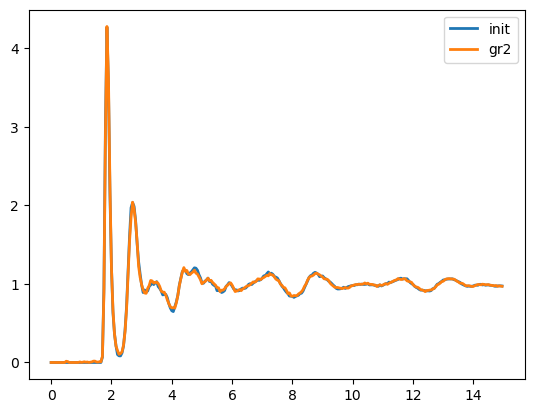

In [ ]:
r, gr2 = rdf.rdf(
        scene.ase_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr2 = gr2.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label='init', lw=2)
ax.plot(r, gr2, label='gr2', lw=2)
# ax.plot(r, gr2, label='gr2', linestyle='dotted', lw=2)
ax.legend() 
plt.show()
    

In [ ]:
# from czone.generator import AmorphousGenerator
# gen = AmorphousGenerator(...)
# vol = Volume(..., generator=gen)
# vol.populate_atoms()
# voronoi_cells = [...]
# for cell in voronoi_cells:
#     new_mol = Molecule(..., pos=volatoms[cell.check_if_interior(vol.atoms),:])
#     cell.generator = new_mol
# # transform the voronoi cells and add to a scene

## not Czone method
1. get random points in volume ( > r from edge)
2. select all atoms in that block, get positions relative to center of the block 
3. apply rotation matrix to all of the positions
4. replace positions in the atoms object with the new ones

5. allow pbcs

In [ ]:
starting_block = atoms.copy()

print(starting_block.get_cell().array)

box_s2 = 10
cpoint = np.random.rand(3) * np.array([np.diag(starting_block.cell)])
cpoint

[[ 88.84597917   0.           0.        ]
 [  0.          90.52096314   0.        ]
 [  0.           0.         228.25698543]]


array([0.41315574, 0.45017525, 0.62592292])

In [22]:
np.diag(starting_block.cell)

array([ 88.84597917,  90.52096314, 228.25698543])